In [1]:
import vr1
from vr1.core import FuelAssembly, Lattice
from vr1.settings import VR1Settings
from vr1.writer import WriterOpenMC
from vr1.plots import test_plots
from vr1.materials import VR1Materials
from vr1.VR1facility import Facility
import vr1.lattice_units as vlu
import openmc
from vr1.core import core_designs
import vr1.utils
import pke.solver as vr1pke

# Reactor Kinetics

The vr1-openmc package comes with a point kinetics equations (PKE) solver. You can play with this below. The function *rho_t* is passed to the solver as the reactivity within the system. You can make this return whatever you like to see what would happen to the neutron density (AKA power) and the precursor concentration. The units of reactivity are Δk/k, which is equivalent to pcm. 

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Delayed Neutron Precursors'}, xlabel='Time [s]', ylabel='Precursor Concentration'>)

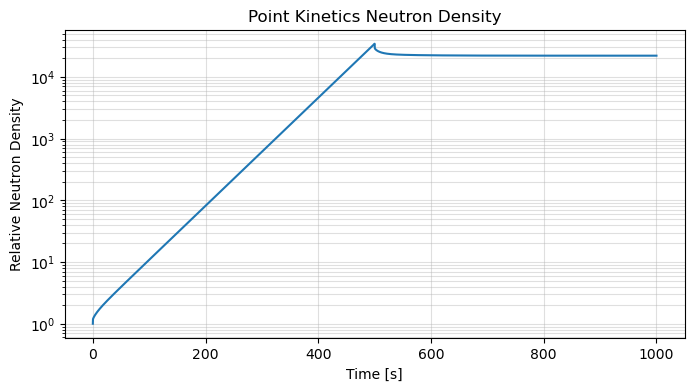

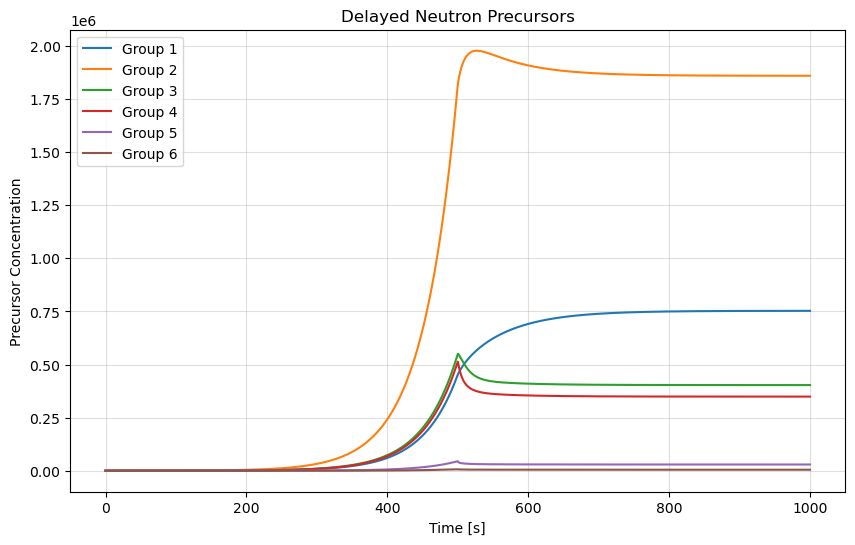

In [87]:
def rho_t(t):
    if t < 500:
        return 1E-3
    else:
        return 0

testpke = vr1pke.PointKineticsEquationSolver(rho_t)
testpke.solve(t_span = (0,1000))
testpke.plot_neutron_density()
testpke.plot_precursors()